# Laboratory Session 6
## K-means Clustering Algorithm

### Input: Dataset X and number of clusters K
### Output: List of centroids M and label vector of data points Y
### Algorithm:
1. Choose K points randomly as initial centroids
2. Assign each data point to a cluster with its closest centroid
3. If the assignment no longer changes, then the algorithm stops
4. Update centroids for clusters by computing the adding average of all data points in the clusters from step 2
5. Repeat step 2

##### Import the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(11)

##### Generate 3 clusters

In [2]:
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
N = 500
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

In [3]:
X = np.concatenate((X0, X1, X2), axis = 0)
K = 3

In [4]:
original_label = np.asarray([0]*N + [1]*N + [2]*N).T

##### Display 3 clusters

In [5]:
def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)
    plt.axis('equal')
    plt.plot()
    plt.show()

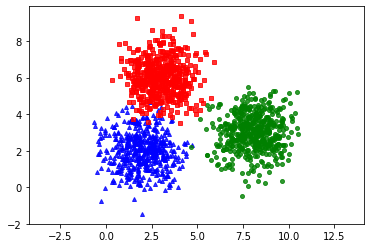

In [6]:
kmeans_display(X, original_label)

##### Initiate centroids

In [7]:
def kmeans_init_centers(X, k):
    # randomly pick k rows of X as initial centers
    return X[np.random.choice(X.shape[0], k, replace=False)]

##### Assign new label (after comparing distances with centroids)

In [8]:
def kmeans_assign_labels(X, centers):
     # calculate pairwise distances btw data and centers
    D = cdist(X, centers)
    # return index of the closest center
    return np.argmin(D, axis = 1)

##### Update new centroids

In [9]:
def kmeans_update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        # collect all points assigned to the k-th cluster
        Xk = X[labels == k, :]
       # take average
        centers[k,:] = np.mean(Xk, axis = 0)
    return centers

##### Verify stop condition

In [10]:
def has_converged(centers, new_centers):
      # return True if two sets of centers are the same
    return (set([tuple(a) for a in centers]) ==
        set([tuple(a) for a in new_centers]))

In [11]:
def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)

Centroids found by the algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


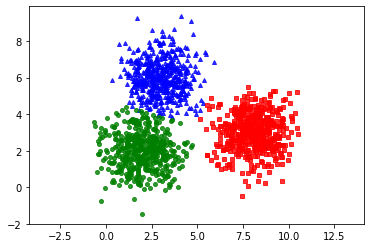

In [12]:
(centers, labels, it) = kmeans(X, K)
print('Centroids found by the algorithm:')
print(centers[-1])
kmeans_display(X, labels[-1])

#### EXERCISE 1:

##### Find out the number of iterations when the algorithm stops.

In [13]:
it

5

#####  Show lists of data points changing clusters for each iteration.

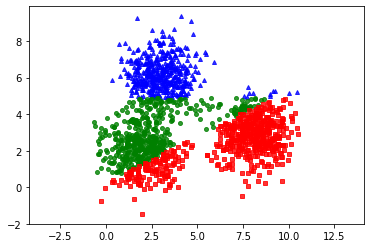

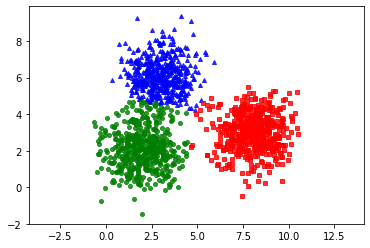

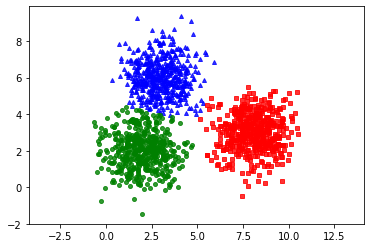

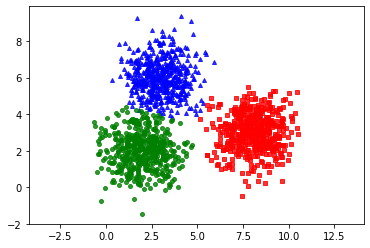

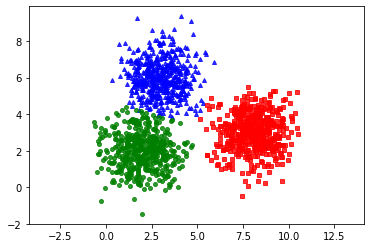

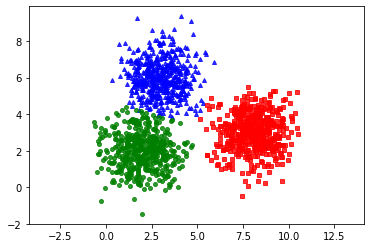

In [14]:
for i in range(it+1):
    kmeans_display(X, labels[i])

#### EXERCISE 2:

##### Propose a solution if the program is not converged. How to verify the optimal results?

We will use the Elbow Method to identify the optimal number of clusters.

In [15]:
from sklearn.cluster import KMeans

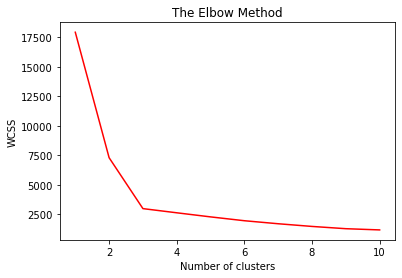

In [16]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

It can be seen from the graph that the optimal result is 3 clusters.

Now we use K++ method to find initial centroids.

In [17]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

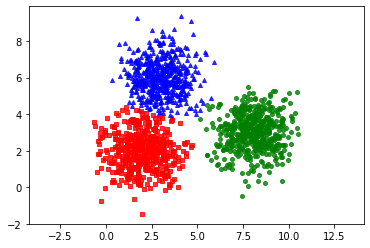

In [18]:
kmeans_display(X, y_kmeans)

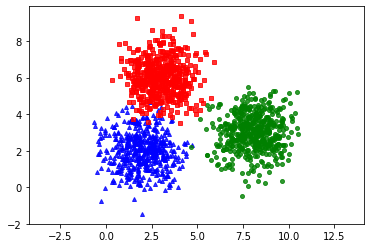

In [19]:
kmeans_display(X, original_label)

Compare the two graphs as shown above, we can claim that they are similar to each other.

Take an example of choosing 2 clusters instead of 3.

In [20]:
kmeans_2 = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
y_kmeans_2 = kmeans_2.fit_predict(X)

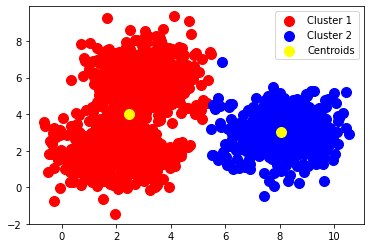

In [23]:
plt.scatter(X[y_kmeans_2 == 0, 0], X[y_kmeans_2 == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans_2 == 1, 0], X[y_kmeans_2 == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1], s = 100, c = 'yellow', label = 'Centroids')
plt.legend()
plt.show()

It can be seen that the result is not optimal.